Downloading...
From: https://drive.google.com/uc?id=1PISGmszIWFGv4EXUhiKmqQ3zAWTgo0Vu
To: /content/IMDB.csv
100%|██████████| 1.38M/1.38M [00:00<00:00, 114MB/s]


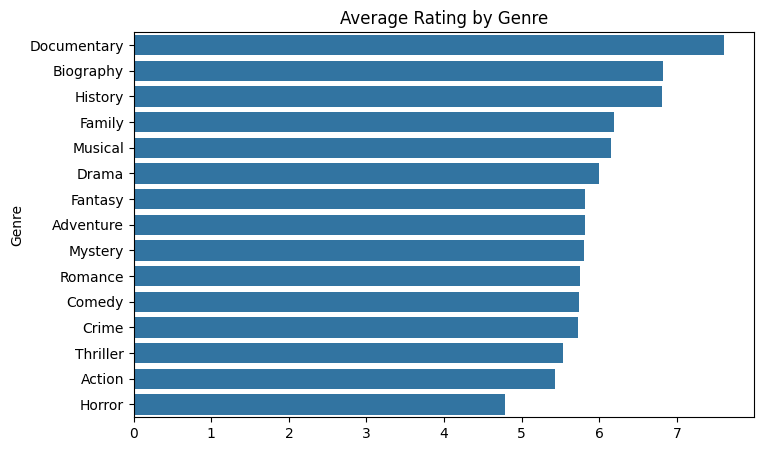


Model Performance:
MAE  : 1.026
RMSE : 1.272
R2   : 0.158


In [13]:
# Optimized Movie Rating Prediction (Faster Version)

!pip install gdown -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Download dataset
file_id = "1PISGmszIWFGv4EXUhiKmqQ3zAWTgo0Vu"
file_name = "IMDB.csv"

gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

# Load dataset
df = pd.read_csv(file_name, encoding="latin1")

# Combine actor columns
df["Actors"] = df[["Actor 1", "Actor 2", "Actor 3"]].values.tolist()

df = df.dropna(subset=["Genre", "Director", "Rating"])

df["Genre"] = df["Genre"].apply(lambda x: [g.strip() for g in str(x).split(",")])
df["Actors"] = df["Actors"].apply(lambda x: [a for a in x if pd.notna(a)])

# -----------------------
# Reduce dimensionality
# -----------------------

# Keep only top 15 genres
all_genres = pd.Series([g for sublist in df["Genre"] for g in sublist])
top_genres = all_genres.value_counts().head(15).index
df["Genre"] = df["Genre"].apply(lambda x: [g for g in x if g in top_genres])

# Keep only top 30 actors
all_actors = pd.Series([a for sublist in df["Actors"] for a in sublist])
top_actors = all_actors.value_counts().head(30).index
df["Actors"] = df["Actors"].apply(lambda x: [a for a in x if a in top_actors])

# Keep only top 20 directors
top_directors = df["Director"].value_counts().head(20).index
df["Director"] = df["Director"].apply(lambda x: x if x in top_directors else "Other")

# -----------------------
# Visualization
# -----------------------

genre_data = []
for i in range(len(df)):
    for genre in df["Genre"].iloc[i]:
        genre_data.append([genre, df["Rating"].iloc[i]])

genre_df = pd.DataFrame(genre_data, columns=["Genre", "Rating"])
avg_rating = genre_df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=avg_rating.values, y=avg_rating.index)
plt.title("Average Rating by Genre")
plt.show()

# -----------------------
# Encoding
# -----------------------

mlb_genre = MultiLabelBinarizer()
mlb_actors = MultiLabelBinarizer()

genre_encoded = pd.DataFrame(
    mlb_genre.fit_transform(df["Genre"]),
    columns=mlb_genre.classes_,
    index=df.index
)

actors_encoded = pd.DataFrame(
    mlb_actors.fit_transform(df["Actors"]),
    columns=mlb_actors.classes_,
    index=df.index
)

director_encoded = pd.get_dummies(df["Director"])
director_encoded.index = df.index

X = pd.concat([genre_encoded, actors_encoded, director_encoded], axis=1)
y = df["Rating"]

# -----------------------
# Train Model (Faster)
# -----------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=80,       # reduced trees
    max_depth=15,          # limit depth
    n_jobs=-1,             # use all CPU cores
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nModel Performance:")
print("MAE  :", round(mean_absolute_error(y_test, y_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
print("R2   :", round(r2_score(y_test, y_pred), 3))


/tmp/ipython-input-4194192522.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='blue') # Diagonal line


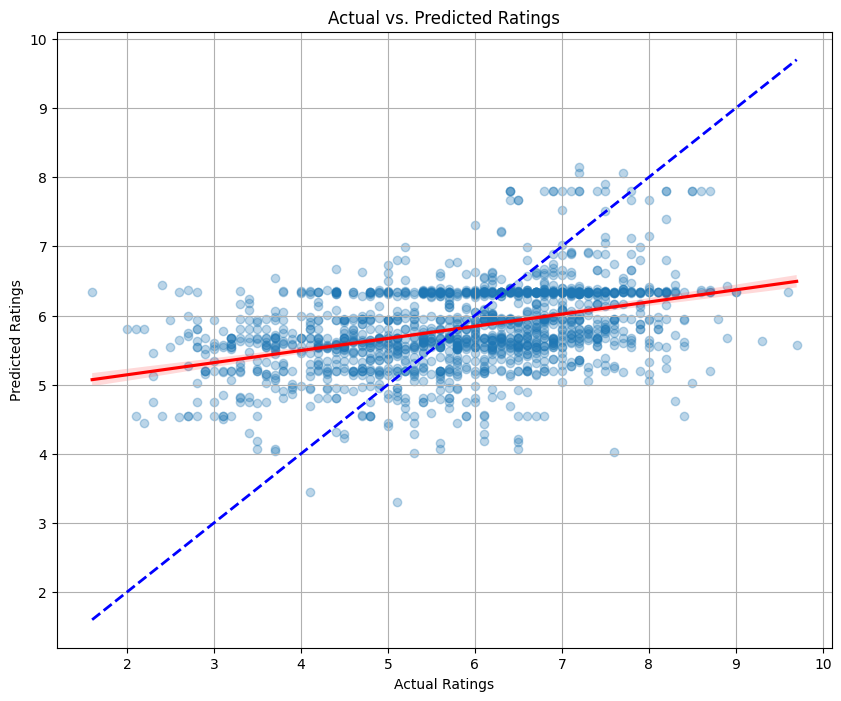

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs. Predicted Ratings')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='blue') # Diagonal line
plt.grid(True)
plt.show()